In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

#from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import KFold, train_test_split, cross_val_score 
from sklearn.metrics import mean_squared_error

plt.style.use('fivethirtyeight')

# Simple Linear Regression 

## Generate Random Data for Notebook

In [2]:
# create data -- polynomial 
# Set a global seed for reproducibility
np.random.seed(42)
X = np.linspace(-2,3,50).reshape(-1, 1)
y = (X**3) - 2*(X**2) + 2*np.random.normal(size=X.shape)

## Plot Dataset

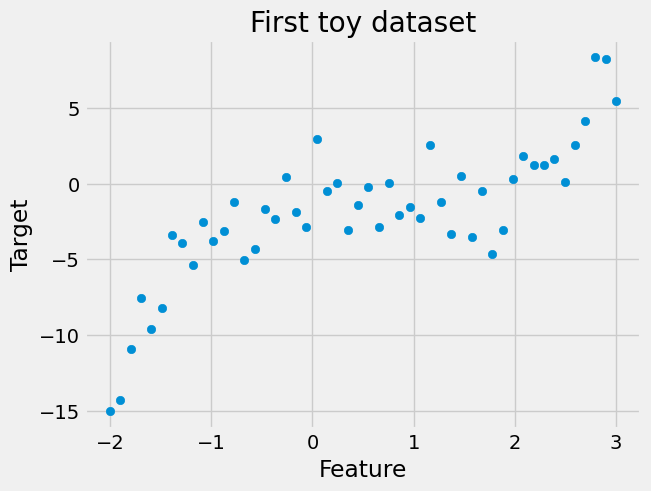

In [3]:
# plot data 
fig,ax = plt.subplots()
ax.scatter(X,y)
ax.set_xlabel('Feature')
ax.set_ylabel('Target')
ax.set_title('First toy dataset');

# Introduction to Scikit-Learn with Simple Linear Regression 

To introuduce sklearn and how models are built with this package, we will start be fitting a simple linear regression model to our dataset.  The 

In [4]:
# Test Train Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
# Build and fit the model
model = LinearRegression().fit(X_train, y_train)

In [6]:
# evalute model with test data
y_pred = model.predict(X_test)
r2 = model.score(y_pred, y_test)
mse = mean_squared_error(y_pred, y_test)
print(f"R^2: {r2:.3f} MSE: {mse:.3f}")

R^2: -3.452 MSE: 6.924


In [7]:
# Print slope and intercept
print('slope:', model.coef_)
print('intercept:', model.intercept_)

slope: [[2.48416062]]
intercept: [-3.14773362]


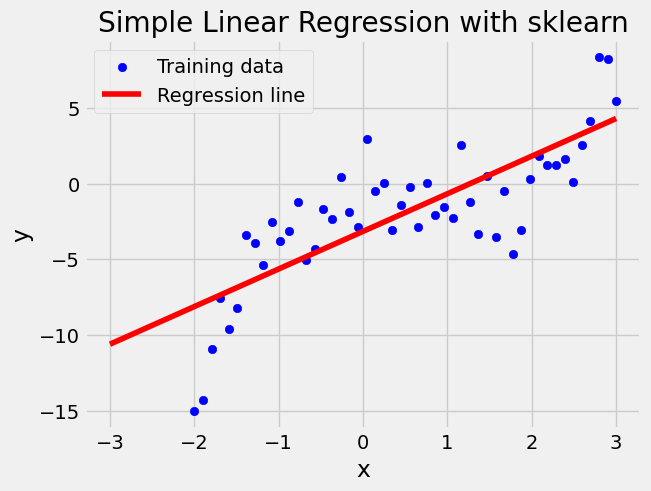

In [8]:
# Plot data points and the regression line
plt.scatter(X, y, color='blue', label='Training data')
x=np.linspace(-3,3,100)
plt.plot(x, model.predict(x.reshape(-1,1)), color='red', label='Regression line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simple Linear Regression with sklearn')
plt.legend()

# Polynomial Regression 

Polynomial regression is a type of regression analysis that models the relationship between an independent variable (or features) and a dependent variable (target) as an n-th degree polynomial. Unlike linear regression, which assumes a straight-line relationship, polynomial regression can capture more complex, curved patterns in data. It is essentially linear regression applied to polynomial features of the inputs.

Polynomial regression with one feature \(x\) and degree \(d\):

$$
\hat{y} = a_0 + a_1 x + a_2 x^2 + \cdots + a_d x^d
$$


Note you can still used Polyomial Regression with multiple features.  Below is an example with two features $(x_1, x_2, \dots, x_n)$:

$$
\hat{y} = a_0 + a_1 x_1 + a_2 x_1^2 + a_3 x_2 + a_4 x_2^2 + a_5 x_1 x_2 + \cdots
$$

### Note: Hyperparameter

When building a polynomial regression model, we will need to select the degree of the polynomial.  The degree of the polynomial is an example of a **hyperparameter**.  Hyperparameters are parameters users select that will impact the performance of ML models.  In the next few cells, we will introduce how to select good value for. hyperparamters 

To build these models in sklearn with one feature we need to engineer features $(x_1, x_2, \dots, x_n)$.  The following sklearn functions do this for you:  

In [9]:
# Build three models of different degrees of polynomials

# Handy feature in sklearn that will automatically create polynomial data 
x3 = PolynomialFeatures(3).fit_transform(X.reshape(len(X),-1))[:,1:]
x30 = PolynomialFeatures(30).fit_transform(X.reshape(len(X),-1))[:,1:]
x30_test = PolynomialFeatures(30).fit_transform(X.reshape(len(X),-1))[:,1:]
print(x3[:5])

[[-2.          4.         -8.        ]
 [-1.89795918  3.60224906 -6.83692169]
 [-1.79591837  3.22532278 -5.79241643]
 [-1.69387755  2.86922116 -4.86010931]
 [-1.59183673  2.53394419 -4.03362545]]


Next, let's build these three polynomial regression models of degree 1, 3 and 30 and plot the results.

In [10]:
# Create three models for various polynomial transformations
model = LinearRegression().fit(X, y)
model3 = LinearRegression().fit(x3, y)
model30 = LinearRegression().fit(x30, y);

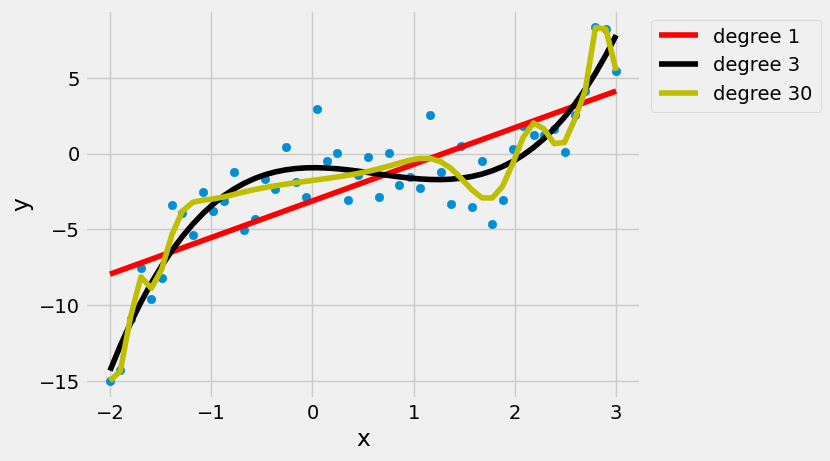

In [11]:
fig,ax = plt.subplots()
ax.scatter(X,y)
ax.plot(X,model.predict(X.reshape(-1,1)),c='r',label='degree 1')
ax.plot(X,model3.predict(x3),c='k',label='degree 3')
ax.plot(X,model30.predict(x30),c='y',label='degree 30')
ax.set_ylabel('y')
ax.set_xlabel('x')
ax.legend(loc='upper left', bbox_to_anchor=(1,1));

## Underfitting vs Overfitting

Underfitting happens when a model is too simple to capture the underlying patterns in the data, resulting in poor performance on both training and new data. For example, fitting a straight line to data that follows a curve will likely miss important trends.

Overfitting occurs when a model is too complex and fits not only the real patterns but also the noise in the training data, causing it to perform well on training data but poorly on new, unseen data. In polynomial regression, a low-degree polynomial may underfit, while a very high-degree polynomial can overfit.

In short, underfitting means the model is not complex enough to learn the data structure, and overfitting means it is too complex and memorizes noise instead of generalizing.

## How to identify Underfitting vs Overfitting? 

In the example above, we can visual see the under and overfitting occuring in the data becasue we ahve a low dimensional problem where we can plot our models predictions.  In realistic problems, we can not do this and we will need to use evaluation metrics to give us clues to what's happening.  In the code below, we demo this process.  The process involves: 

1. Fitting multiple models with different values of the hyperparameter you are exploring.
2. Evaluate the model with both training and testing data seperately. 

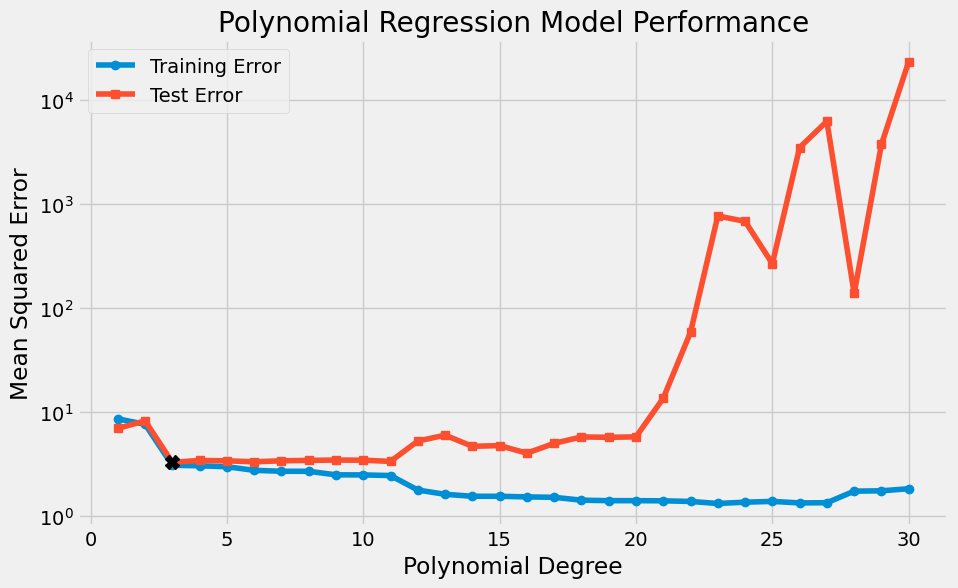

In [12]:


# Store errors
degrees = range(1, 31)
train_errors, test_errors = [], []

for d in degrees:
    # Polynomial features
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # Linear regression
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Errors
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label="Training Error", marker='o')
plt.plot(degrees, test_errors, label="Test Error", marker='s')
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Polynomial Regression Model Performance")
plt.legend()
plt.grid(True)

# Find index of minimum test error
min_index = np.argmin(test_errors)
# Highlight the minimum test error point
plt.plot(degrees[min_index], test_errors[min_index], marker='X', markersize=10,
         color='black', label='Min Test Error')

plt.yscale('log')
plt.show()


We can identify where the model is over and under fitting above based on the following:

1. Underfitting: Both train and test scores are poor  
2. Overfitting: Train scores are very good, but test scores are bad. 

IMPORTANT: Linear Regression models can overfit when to many parameters/features are used! 

# Regularization: Ridge and Lasso Regression 

Regularization is a technique used to prevent overfitting by adding a penalty to a model's loss function. This penalty discourages complexity by shrinking the coefficient values, which helps the model generalize better to unseen data.  When using regulatization with linear regression, it is referred to either Ridge or Lasso regression depending on what loss function you use:

## Lasso

Below is the loss functin used with Lasso regression. It tends to do a good job at eliminating features that are not being used to predict the target. 

$
\text{Lasso Loss} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^m |a_j|
$

## Ridge

Below is the loss functin used with Rdige regression. It tends to do a good job at collectively using all features with some signal without overfitting. 

$
\text{Ridge Loss} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \frac{1}{2} \alpha \sum_{j=1}^m a_j^2
$

/Users/jrduncan/Desktop/Fall_tutorial_25/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.760e+01, tolerance: 1.038e-01
  model = cd_fast.enet_coordinate_descent(


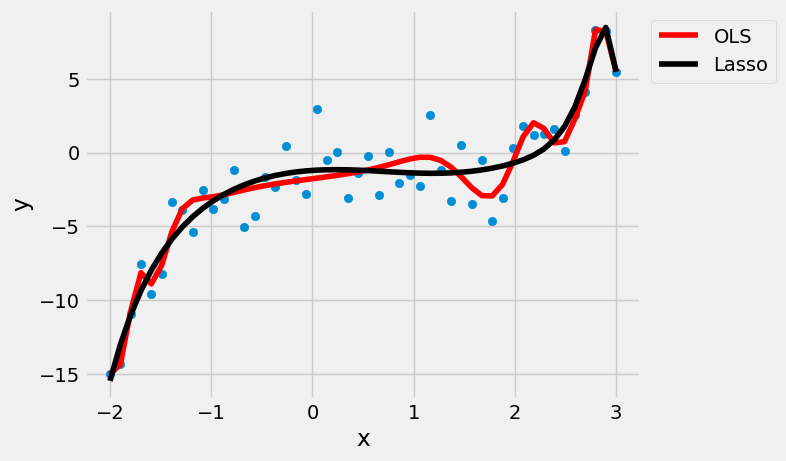

In [13]:
# build ridge model 
model_lasso30 = Lasso(alpha=0.01)  #normalize=True)  # change alpha to see how model changes
model_lasso30.fit(x30, y);

fig,ax = plt.subplots()
ax.scatter(X,y)
ax.plot(X,model30.predict(x30),c='r',label='OLS')
ax.plot(X,model_lasso30.predict(x30),c='k',label='Lasso')
ax.set_ylabel('y')
ax.set_xlabel('x')
ax.legend(loc='upper left', bbox_to_anchor=(1,1));

# Logistic Regression 

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs

In [15]:
# Generate a toy dataset with 2 features and binary target
X, y = make_blobs(n_samples=200, centers=2, n_features=2,
                  cluster_std=3.0,  # Larger std means more overlap
                  random_state=42)

# Test Train Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
# Create and fit logistic regression model
model = LogisticRegression()
model.fit(X, y);

Text(0.5, 1.0, 'Logistic Regression Decision Boundary')

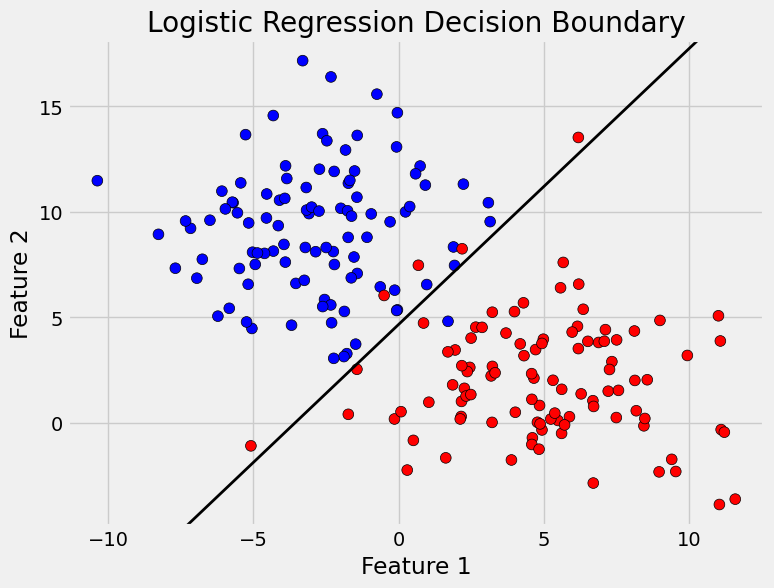

In [17]:
# Plotting the points and decision boundary
plt.figure(figsize=(8, 6))

# Scatter plot of the data points colored by class
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=60)

# Create grid to evaluate model
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict the probability for the grid points
probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

# Plot decision boundary at 0.5 probability
plt.contour(xx, yy, probs, levels=[0.5], linewidths=2, colors='black')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')

In [18]:
from sklearn.metrics import classification_report  # includes various metrics for evaluating classification models
y_pred=model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        37
           1       1.00      0.96      0.98        23

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



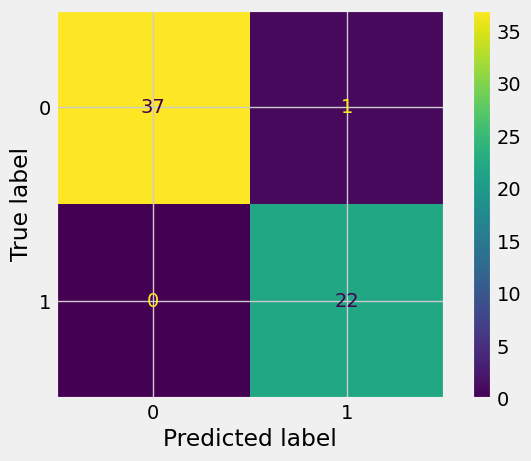

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # computes and visually displays the confusion matrix 
cm=confusion_matrix(y_pred, y_test) 
cm_display = ConfusionMatrixDisplay(cm).plot()
